**<h2 style="color:green"> Product Retail Prices per month from 2017-2025</h2>**
**<h2 style="color:green"> Gruop Number: 22</h2>**
**<h2 style="color:green">Name of student: Tamar Sharabi</h2>**

From: https://www.kaggle.com/datasets/aradhanahirapara/product-retail-price-survey-2017-2025?resource=download&select=Retail_Prices_of+_Products.csv

Kaggle sources: https://www150.statcan.gc.ca/t1/tbl1/en/cv.action?pid=1810024501

# Libraries

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots
import plotly.express as px
import calendar
import matplotlib.dates as mdates
import os

In [5]:
df = pd.read_csv(r"Retail_Prices_of _Products.csv")

In [6]:
df.shape

(118482, 12)

In [7]:
numeric_columns=df.select_dtypes('number').columns
len(numeric_columns)
numeric_columns

Index(['Year', 'VALUE', 'Total tax rate', 'Value after tax', 'COORDINATE'], dtype='object')

In [8]:
categorical_columns=df.select_dtypes('object').columns
len(categorical_columns)
categorical_columns

Index(['Month', 'GEO', 'Product Category', 'Products', 'Taxable', 'Essential',
       'UOM'],
      dtype='object')

<div dir="rtl">בדיקת ערכים חסרים

In [10]:
df.isnull().sum()

Year                0
Month               0
GEO                 0
Product Category    0
Products            0
VALUE               0
Taxable             0
Total tax rate      0
Value after tax     0
Essential           0
COORDINATE          0
UOM                 0
dtype: int64

<div dir="rtl"> כדי לעשות קורלציה ולבדוק קשרים בן העמודות, השתמשתי get dummies בשביל לעשות קורלציה גם על העמודות הקטגוריות.

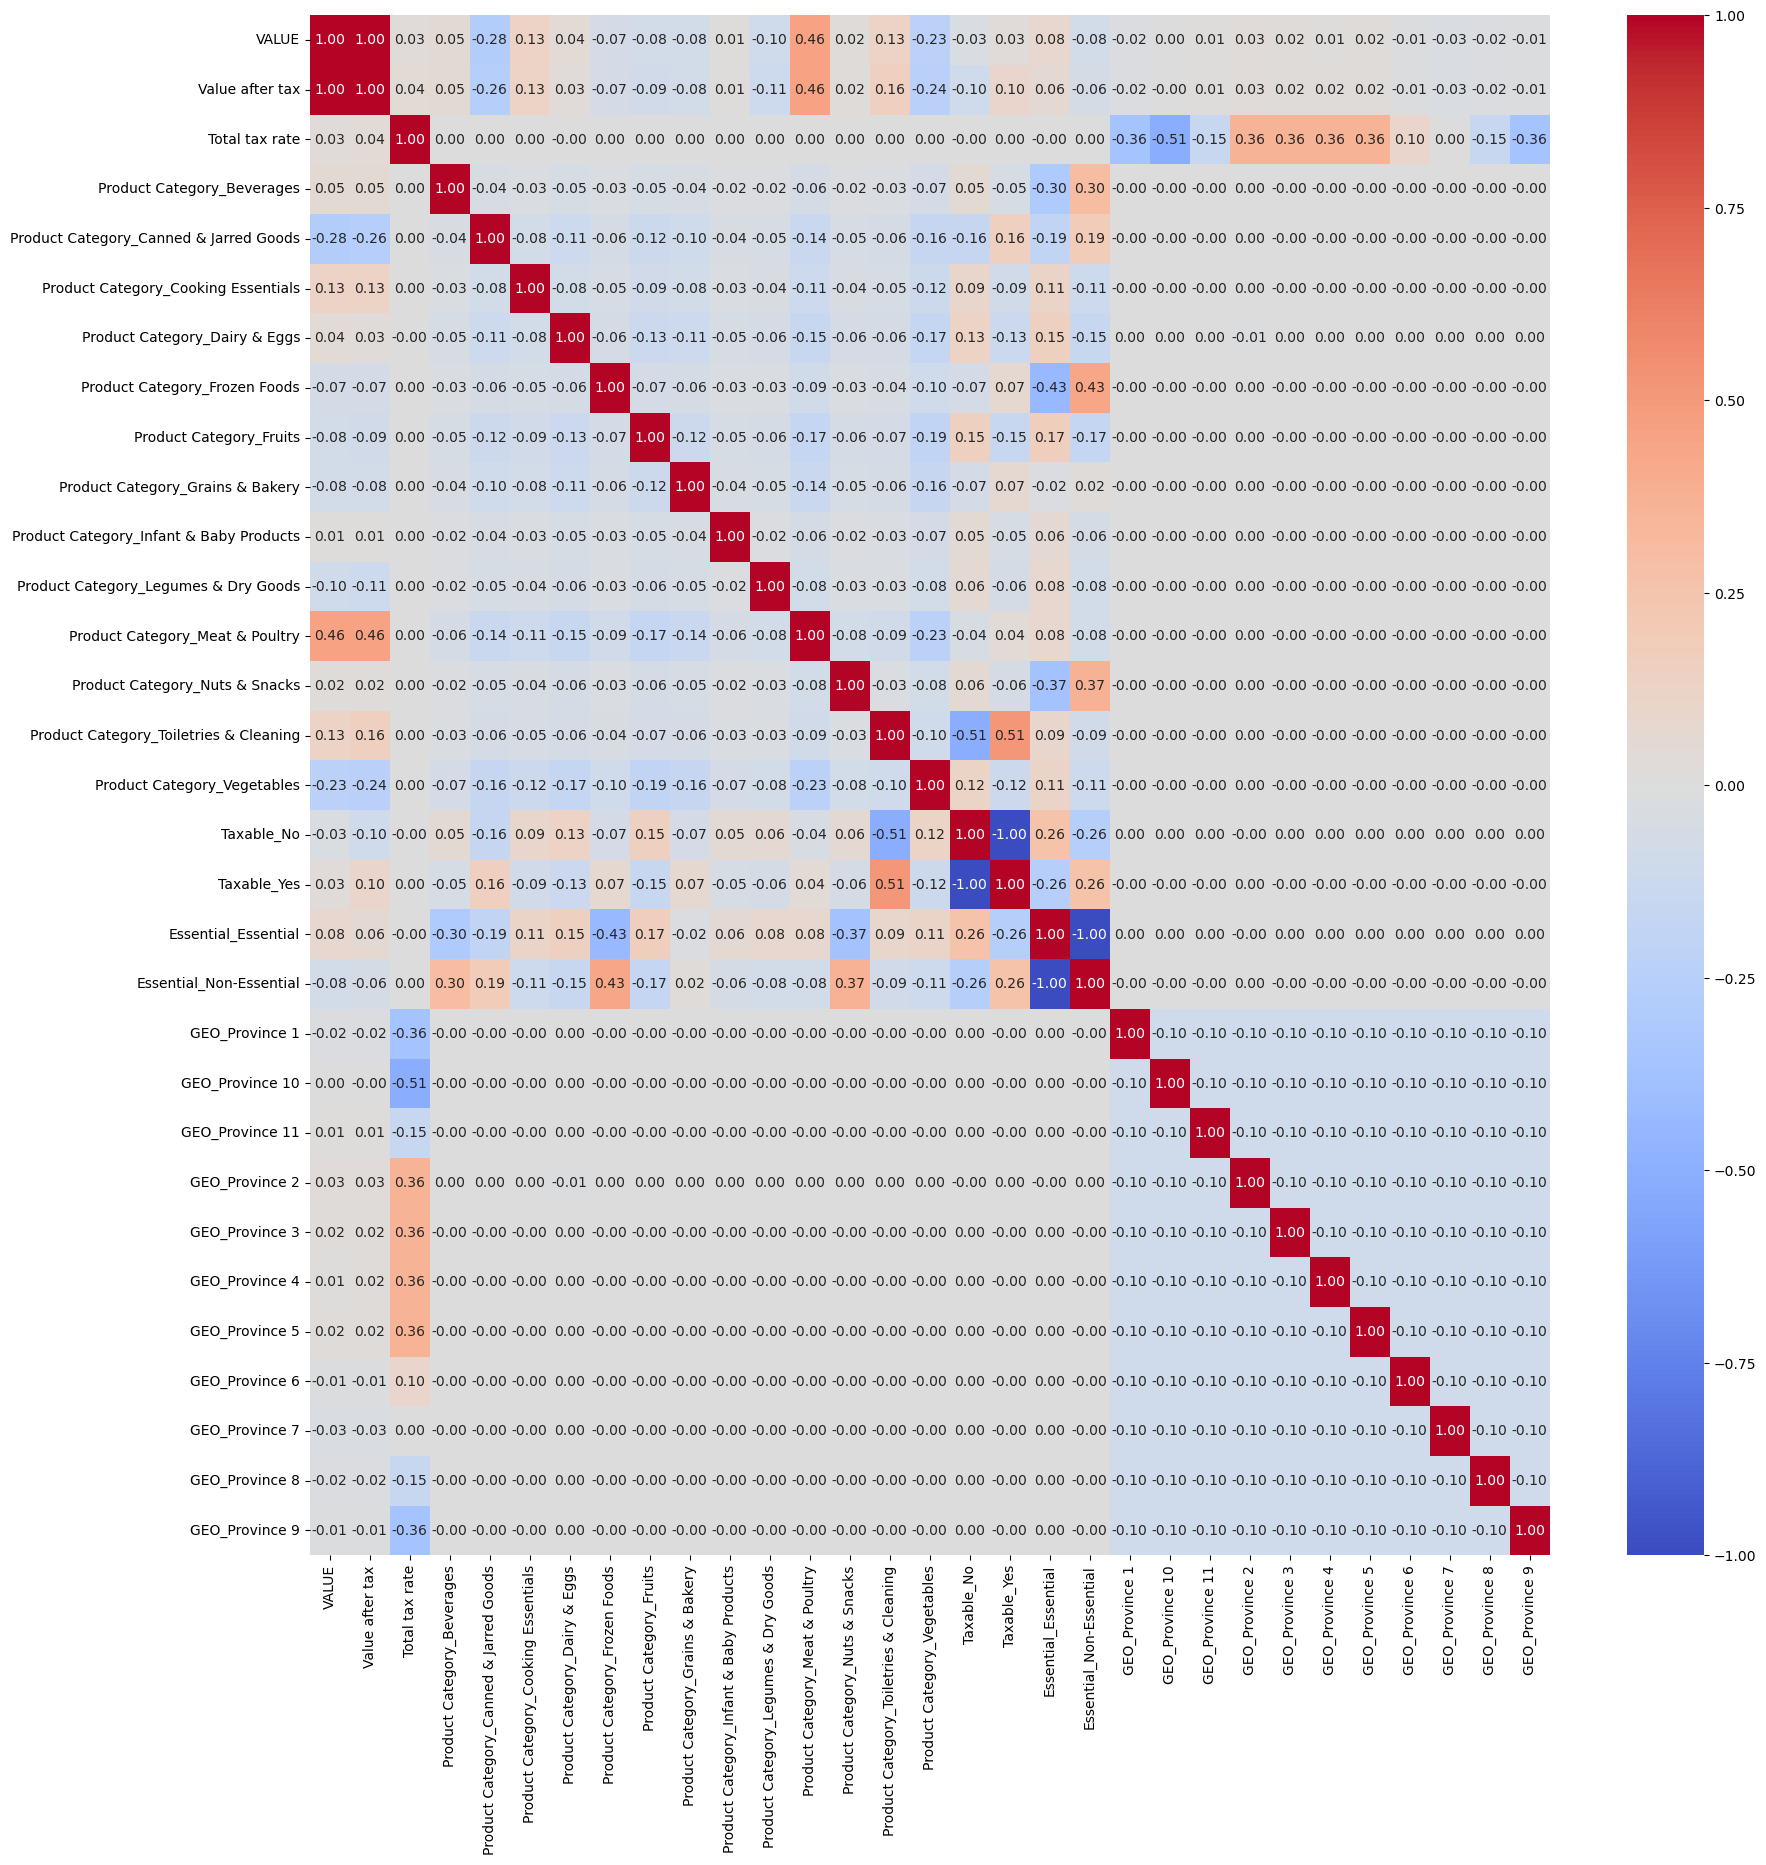

In [12]:
numeric_col=[ 'VALUE','Value after tax','Total tax rate']
categorical_col=['Product Category', 'Taxable', 'Essential','GEO']
all_col = numeric_col + categorical_col
df_dum = pd.get_dummies(df[all_col])
all_correlation_matrix = df_dum.corr( numeric_only = False,method = 'spearman' ).round(2)
plt.figure(figsize=(20,20))
sns.heatmap(data=all_correlation_matrix,cmap='coolwarm', annot=True,fmt=".2f")
plt.show()

<div dir="rtl">ראיתי שיש קשר בין המוצרים שחייבים במס לבין מוצרים לא חיוניים אז בדקתי בגרף כמה זה באחוזים

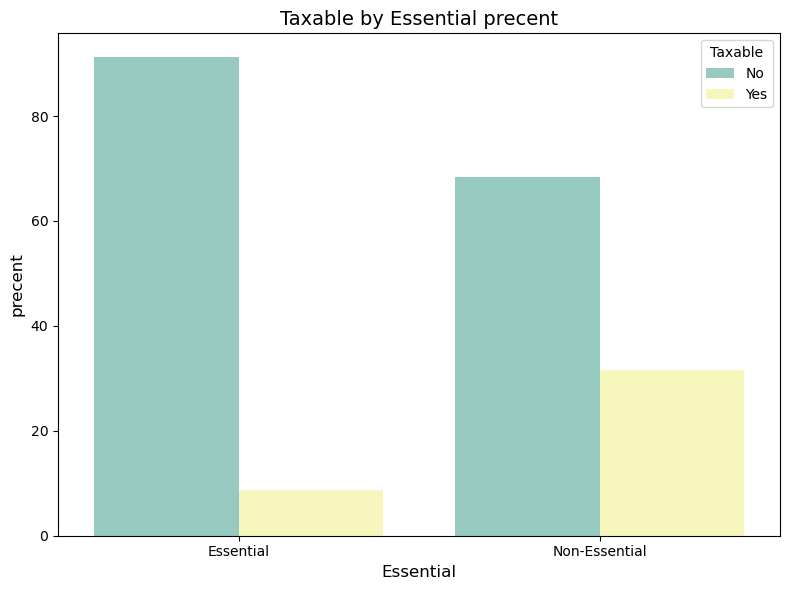

In [14]:
count_df = df.groupby(['Essential', 'Taxable']).size().reset_index(name='count')
count_df['percent'] = count_df.groupby('Essential')['count'].transform(lambda x: 100 * x / x.sum())

plt.figure(figsize=(8, 6))
sns.barplot(data=count_df, x='Essential', y='percent', hue='Taxable',palette='Set3')

plt.ylabel("precent" ,fontsize=12)
plt.xlabel("Essential",fontsize=12)
plt.title("Taxable by Essential precent", fontsize=14)
plt.legend(title='Taxable')
plt.tight_layout()
plt.show()

<div dir="rtl"> מהנתונים רואים שרוב המוצרים שחייבים במס הם לא חיוניים. רציתי לראות איזה סוג מוצרים נחשבים לא חיוניים לפי הקובץ.

In [16]:
Non_Essential = df[df['Essential'] == 'Non-Essential']
category_counts = Non_Essential['Product Category'].value_counts().reset_index()
category_counts.columns = ['Product Category', 'Count']
category_counts

,Product Category,Count
0,Canned & Jarred Goods,4312
1,Frozen Foods,4312
2,Nuts & Snacks,3234
3,Meat & Poultry,2156
4,Vegetables,2156
5,Grains & Bakery,2156
6,Beverages,2156


<div dir="rtl">מוצרים "לא חיוניים" שחייבים במס:

In [18]:
Non_essential_taxable = df[(df['Essential'] == 'Non-Essential') & (df['Taxable'] == 'Yes')]
result = Non_essential_taxable[['Product Category', 'Taxable', 'Essential']].drop_duplicates()
result 

,Product Category,Taxable,Essential
18,Meat & Poultry,Yes,Non-Essential
64,Frozen Foods,Yes,Non-Essential
70,Grains & Bakery,Yes,Non-Essential
88,Canned & Jarred Goods,Yes,Non-Essential


<div dir="rtl"> מוצרים "חיוניים" שחייבים במס:

In [20]:
Essential_taxable = df[(df['Essential'] == 'Essential') & (df['Taxable'] == 'Yes')]
result2 = Essential_taxable[['Product Category', 'Taxable', 'Essential']].drop_duplicates()
result2 

,Product Category,Taxable,Essential
12,Meat & Poultry,Yes,Essential
58,Vegetables,Yes,Essential
69,Grains & Bakery,Yes,Essential
106,Toiletries & Cleaning,Yes,Essential


<div dir="rtl">לקחתי את שתי הקטגוריות שנחשבות להכי "לא חיוניות" ושחייבות במיסוי ובדקתי את הערך שלהן לפני ואחרי מיסוי

Text(0, 0.5, 'Value before tax')

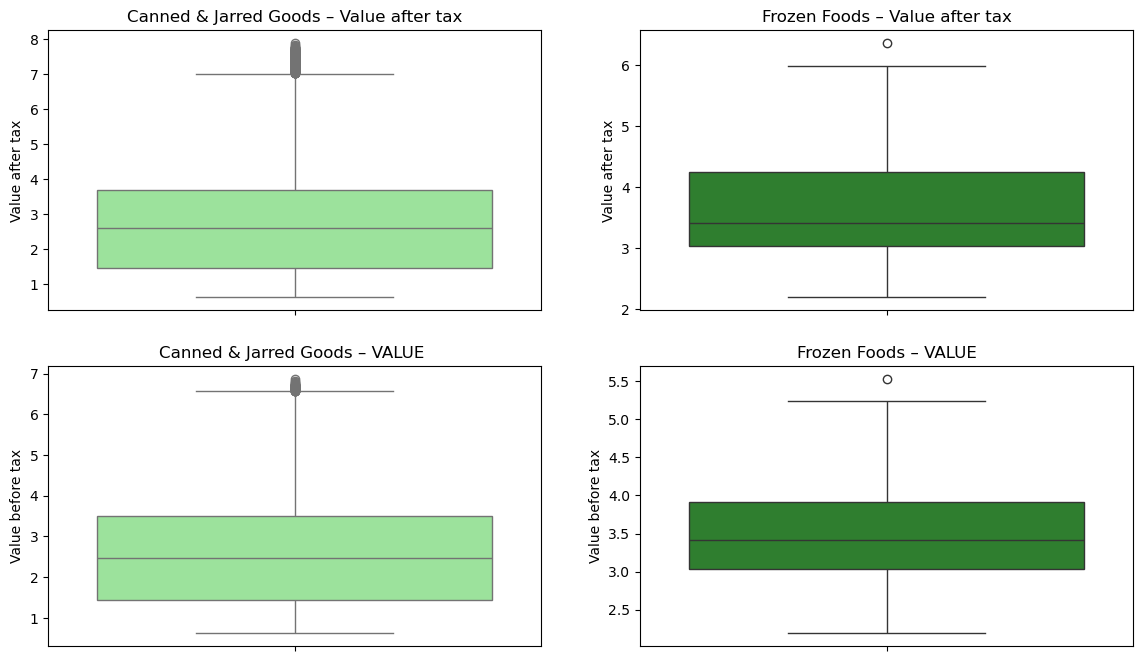

In [22]:
canned_df = df[df['Product Category'] == 'Canned & Jarred Goods'][['Product Category', 'Value after tax']]
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
sns.boxplot(data=canned_df, y='Value after tax', color='lightgreen')
plt.title("Canned & Jarred Goods – Value after tax")
plt.ylabel("Value after tax")
plt.xlabel("")

frozen_df = df[df['Product Category'] == 'Frozen Foods']

plt.subplot(2, 2, 2)
sns.boxplot(data=frozen_df, y='Value after tax', color='forestgreen')
plt.title("Frozen Foods – Value after tax")
plt.xlabel("")
plt.ylabel("Value after tax")


canned_df1 = df[df['Product Category'] == 'Canned & Jarred Goods'][['Product Category', 'VALUE']]
plt.subplot(2, 2, 3)
sns.boxplot(data=canned_df1, y='VALUE', color='lightgreen')
plt.title("Canned & Jarred Goods – VALUE ")
plt.ylabel("Value before tax")
plt.xlabel("")


plt.subplot(2, 2, 4)
sns.boxplot(data=frozen_df, y='VALUE', color='forestgreen')
plt.title("Frozen Foods – VALUE")
plt.xlabel("")
plt.ylabel("Value before tax")



<div dir="rtl"> וגם את סוג קטגוריית המוצרים הכי "חיונית":

Text(0.5, 0, '')

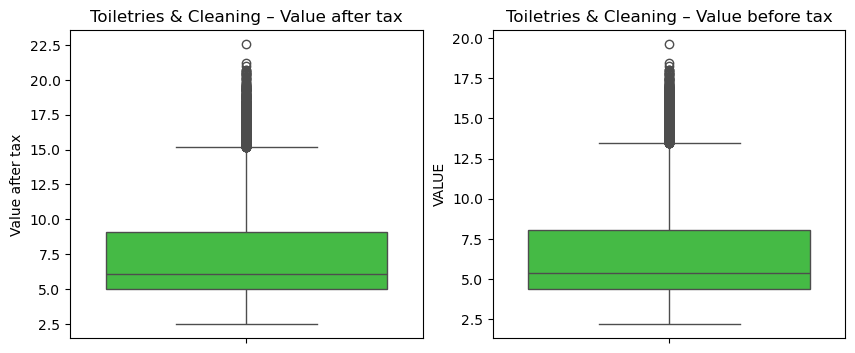

In [24]:
Toli_df = df[df['Product Category'] == 'Toiletries & Cleaning'][['Product Category', 'Value after tax']]
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=Toli_df, y='Value after tax', color='limegreen')
plt.title("Toiletries & Cleaning – Value after tax")
plt.ylabel("Value after tax")
plt.xlabel("")

Toli_df2 = df[df['Product Category'] == 'Toiletries & Cleaning'][['Product Category', 'VALUE']]
plt.subplot(1, 2, 2)
sns.boxplot(data=Toli_df2, y='VALUE', color='limegreen')
plt.title("Toiletries & Cleaning – Value before tax")
plt.ylabel("VALUE")
plt.xlabel("")


<div dir="rtl">נראה לפי הנתונים שהמס מעלה קצת את ערך המוצרים שנחשבים "לא חיוניים" אבל לא ברמה משמעותית, ושלמוצרים "החיוניים" יש יותר השפעה של שיעור המס על המחיר. נבדוק אם יש פער בין ערך המוצרים ה"לא חיוניים" לבין ערך המוצרים "החיוניים"  

In [26]:
Taxable_df1 = df[df['Taxable'] == 'No']
avg_value = Taxable_df1.groupby('Essential')['VALUE'].mean().reset_index()
avg_value.columns = ['Essential', 'Average VALUE']
avg_value

,Essential,Average VALUE
0,Essential,5.790735
1,Non-Essential,3.800980


In [27]:
Taxable_df2 = df[df['Taxable'] == 'Yes']
avg_value_after_tax = Taxable_df2.groupby('Essential')['Value after tax'].mean().reset_index()
avg_value_after_tax.columns = ['Essential', 'Average Value']
avg_value_after_tax

,Essential,Average Value
0,Essential,6.168040
1,Non-Essential,4.556979


C:\Users\User\AppData\Local\Temp\ipykernel_13996\3357470229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_value_after_tax, x='Essential', y='Average Value', palette='Set2')


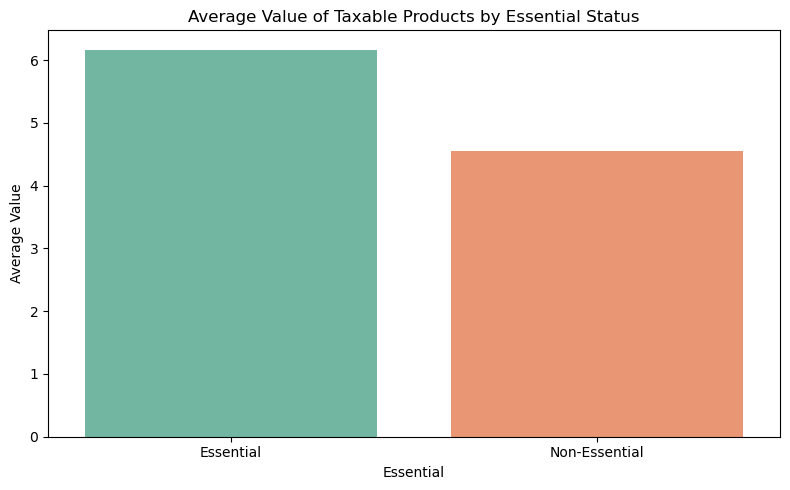

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_value_after_tax, x='Essential', y='Average Value', palette='Set2')

plt.title('Average Value of Taxable Products by Essential Status')
plt.xlabel('Essential')
plt.ylabel('Average Value')
plt.tight_layout()
plt.show()

<div dir="rtl">מהגרף רואים בבירור שערך המוצרים החיוניים גבוה יותר מערך מוצרים הלא חיוניים 

<h2 dir="rtl" style="color:green">מסקנה מספר 1- ההבדלים בין מוצרים חיוניים ולא חיוניים והשפעותיהם</h2>


**<div dir="rtl">בדקתי את הקשר בין מוצרים חיוניים/לא חיוניים לבין מוצרים החייבים או לא חייבים במיסוי. ראינו שרוב המוצרים שחייבים במיסוי הם לא חיוניים. 
רציתי לבדוק עוד זוויות והשוויתי את ערך המוצרים ה"לא חיוניים" לפני מיסוי ואחרי. הפער היה יחסית קטן. רציתי לבדוק עוד הבדלים והשפעות בין מוצרים חיוניים ולא חיוניים החייבים במס, לאחר בדיקה של ערך המוצרים החיוניים והלא חיוניים רואים בבירור שערך המוצרים החיוניים גבוה יותר.
לכן המסקנה לפי נתונים אלו היא שלמרות שמוצרים חיוניים פחות מחוייבים במס, הם עדיין עם ערך גבוה יותר. היצרנים יודעים שלמרות המחיר הגבוה, אלו מוצרים שנרכוש בתדירות יותר גבוהה ומעניין לראות שמה שמשפיע יותר הוא לא שיעור המס אלא האם המוצר הוא חיוני או לא.**  

<div dir="rtl">רציתי לבדוק את שיעור המס ומה הם הגורמים שמשפיעים עליו לירידה או לעלייה. נבדוק לפי איזורים בקנדה האם יש הבדל

In [33]:
avg_tax_by_geo = df.groupby('GEO')['Total tax rate'].mean().reset_index()
avg_tax_by_geo

,GEO,Total tax rate
0,Province 1,11.000
1,Province 10,5.000
2,Province 11,12.000
3,Province 2,15.000
4,Province 3,15.000
5,Province 4,15.000
6,Province 5,15.000
7,Province 6,14.975
8,Province 7,13.000
9,Province 8,12.000


<div dir="rtl">בדקתי בוויקיפדיה על איזור מספר 10 בקנדה כי ראיתי ששיעור המס שלו בבמוצע נמוך משמעותית משאר באיזורים. איזור זה הוא איזור עם האחוז הכי קטן מהאוכלוסייה בקנדה אך עם הצפיפות הכי גבוהה, האנשים שם משתכרים בעיקר מחקלאות ,דייג ותיירות ולכן שיעור המס שם הוא נמוך משמעותית.
    <div dir="rtl">
קישור למקור- 
    https://he.wikipedia.org/wiki/%D7%94%D7%A4%D7%A8%D7%95%D7%91%D7%99%D7%A0%D7%A6%D7%99%D7%95%D7%AA_%D7%95%D7%94%D7%98%D7%A8%D7%99%D7%98%D7%95%D7%A8%D7%99%D7%95%D7%AA_%D7%A9%D7%9C_%D7%A7%D7%A0%D7%93%D7%94

In [35]:
month_map = {'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12}
df['Month_num'] = df['Month'].map(month_map)
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month_num'], day=1))
tax_by_geo_time = df.groupby(['GEO', 'Date'])['Total tax rate'].mean().reset_index()
tax_by_geo_time 

,GEO,Date,Total tax rate
0,Province 1,2017-01-01,11.0
1,Province 1,2017-02-01,11.0
2,Province 1,2017-03-01,11.0
3,Province 1,2017-04-01,11.0
4,Province 1,2017-05-01,11.0
...,...,...,...
1073,Province 9,2024-10-01,11.0
1074,Province 9,2024-11-01,11.0
1075,Province 9,2024-12-01,11.0
1076,Province 9,2025-01-01,11.0


.<div dir="rtl">אחרי בדיקה של שיעור המס לפי איזור התלוי בזמן, רואים ששיעור המס נשאר קבוע ויציב. נערוך השוואה בין צריכת המוצרים של האיזור עם שיעור המס הכי נמוך לבין האיזור עם שיעור המס הכי גבוה

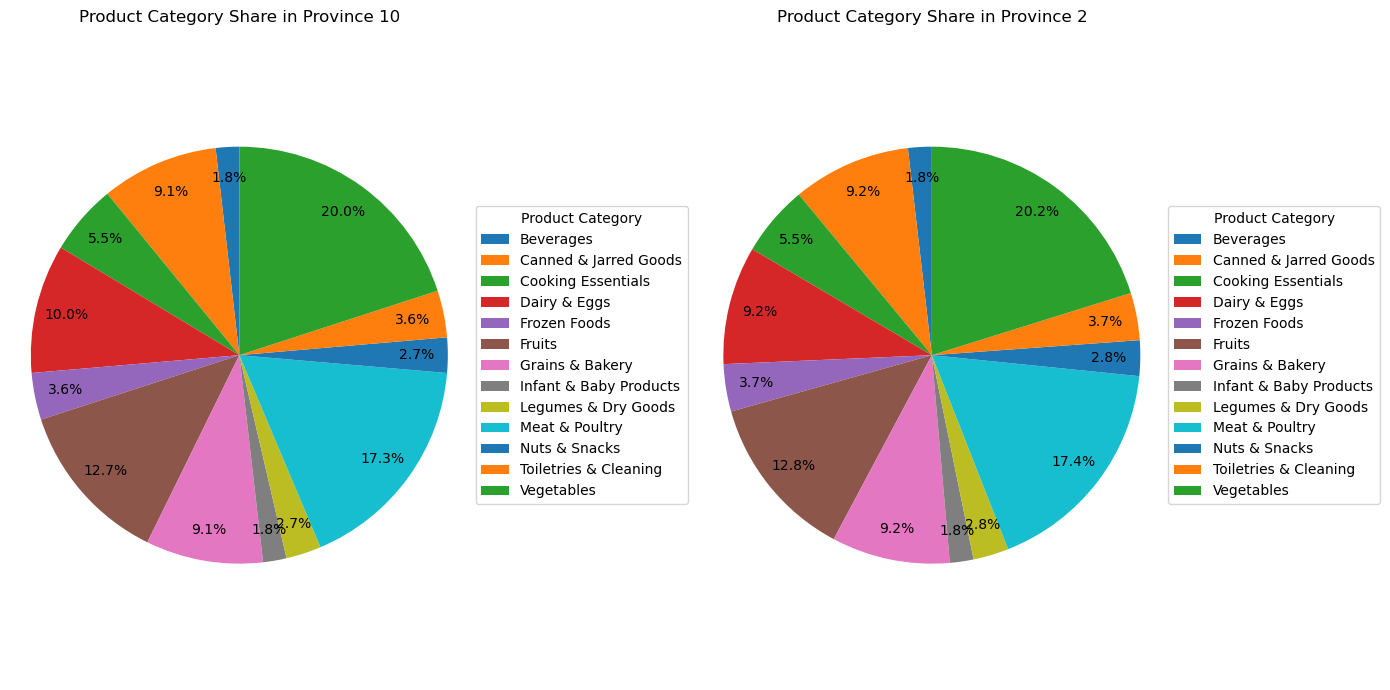

In [37]:
selected_provinces = ['Province 2', 'Province 10']
Province_df = df[df['GEO'].isin(selected_provinces)]
Consumption_by_GEO= Province_df.groupby(['GEO', 'Product Category']).size().unstack(fill_value=0)
percentages = Consumption_by_GEO.div(Consumption_by_GEO.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for i, province in enumerate(percentages.index):
    wedges, texts, autotexts = axes[i].pie(percentages.loc[province],labels=None,autopct='%1.1f%%',startangle=90,pctdistance=0.85)
    axes[i].legend(wedges, percentages.columns, title="Product Category", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    axes[i].set_title(f'Product Category Share in {province}')
    axes[i].axis('equal')

plt.tight_layout()
plt.show()


<div dir="rtl">ההבדל המהותי היחיד שאפשר לראות מהתפלגות הנתונים בגרף הוא שב - province 10 (האיזור עם שיעור המס הנמוך ביותר) <div dir="rtl">צריכת מוצרי חלב וביצים, שהם מוצרי בסיס, גבוהה יותר מאחד האיזורים שבו שיעור המס הוא הגבוה ביותר. נבדוק האם יש הבדל בערך המוצרים .

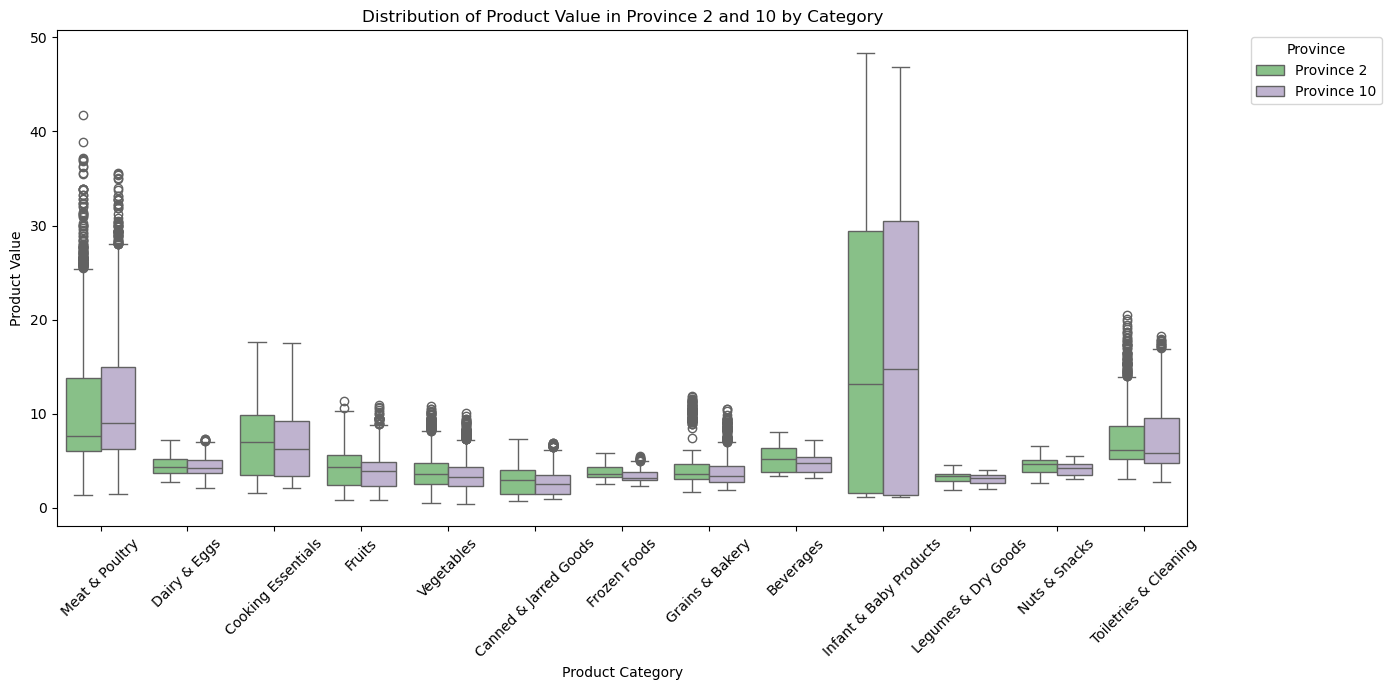

In [39]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=Province_df, x='Product Category', y='Value after tax', hue='GEO',palette='Accent')

plt.xticks(rotation=45)
plt.title('Distribution of Product Value in Province 2 and 10 by Category')
plt.xlabel('Product Category')
plt.ylabel('Product Value')
plt.legend(title='Province', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<div dir="rtl">נסתכל יותר בקירוב על הקטגוריות החריגות

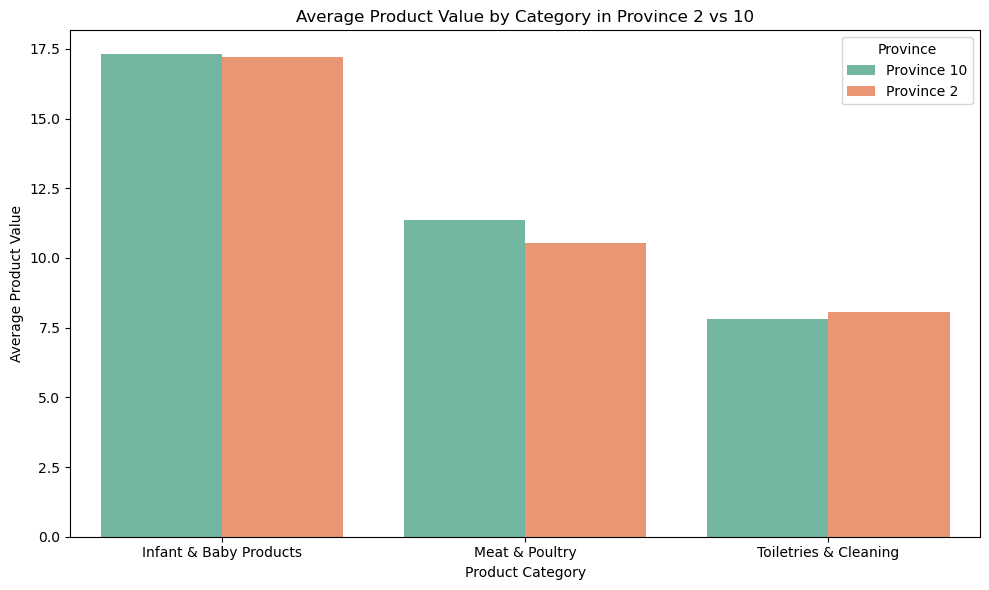

In [41]:
selected_provinces = ['Province 2', 'Province 10']
selected_categories = ['Meat & Poultry', 'Infant & Baby Products', 'Toiletries & Cleaning']

filtered_df = df[
    (df['GEO'].isin(selected_provinces)) &
    (df['Product Category'].isin(selected_categories))
]

grouped = filtered_df.groupby(['Product Category', 'GEO'])['Value after tax'].mean().reset_index()

plt.figure(figsize=(10, 6))
plot = sns.barplot(data=grouped, x='Product Category', y='Value after tax', hue='GEO',palette='Set2')

plt.title('Average Product Value by Category in Province 2 vs 10')
plt.xlabel('Product Category')
plt.ylabel('Average Product Value')

handles, labels = plot.get_legend_handles_labels()
plt.legend(title='Province', handles=handles, labels=labels)

plt.tight_layout()
plt.show()

<div dir="rtl"> אנו רואים שברוב קטגוריות המוצרים, באיזור עם שיעור המס הגבוה יותר גם ערך המוצרים גבוה יותר, בדקנו את המקרים החריגים כדי לראות אם ישנה השפעה נוספת,וראינו שהפערים הם לא מאוד גדולים

<h2 dir="rtl" style="color:green">מסקנה מספר 2 - הגורמים לעלייה/ירידה של שיעור המס</h2> 


**<div dir="rtl">רציתי לבדוק מהם הגורמים לעלייה/ירידה של שיעור המס, אז אמנם שיעור המס הוא קבוע לאורך השנים אך רואים בבירור את ההתפלגות בין האיזורים השונים בקנדה וראיתי שיש קשר בין גובה שיעור המס לגובה המחיר של המוצרים הנמכרים. 
באיזור עם שיעור המס הנמוך ביותר רואים שהמחירים יותר זולים מאיזורים עם שיעור המס הגבוה ביותר. לכן, המסקנה שמצאתי מהנתונים היא שההשפעה העיקרית על גובה שיעור המס היא סוג האוכלוסייה ואופן הצריכה שלה.**

<div dir="rtl"> נבדוק האם יש שינוי במחירי המוצרים לאורך זמן

<div dir="rtl"> נתונים על השורה עם הערך הכי גבוה:

In [47]:
highest_value_product = df.loc[df['VALUE'].idxmax()]
highest_value_product

Year                                       2025
Month                                  February
GEO                                  Province 6
Product Category                 Meat & Poultry
Products            Beef rib cuts, per kilogram
VALUE                                     48.45
Taxable                                      No
Total tax rate                           14.975
Value after tax                           48.45
Essential                             Essential
COORDINATE                                 5.41
UOM                                     Dollars
Month_num                                     2
Date                        2025-02-01 00:00:00
Name: 117825, dtype: object

<div dir="rtl"> נתונים על השורה עם הערך הכי נמוך:

In [49]:
lowest_value_product = df.loc[df['VALUE'].idxmin()]
lowest_value_product

Year                               2017
Month                           October
GEO                          Province 7
Product Category             Vegetables
Products                    Limes, unit
VALUE                               0.3
Taxable                              No
Total tax rate                     13.0
Value after tax                     0.3
Essential                 Non-Essential
COORDINATE                         6.45
UOM                             Dollars
Month_num                            10
Date                2017-10-01 00:00:00
Name: 11576, dtype: object

In [50]:
df['Product Category'].value_counts().reset_index()

,Product Category,count
0,Vegetables,23716
1,Meat & Poultry,20482
2,Fruits,15092
3,Dairy & Eggs,11760
4,Canned & Jarred Goods,10780
5,Grains & Bakery,10780
6,Cooking Essentials,6468
7,Frozen Foods,4312
8,Toiletries & Cleaning,4312
9,Legumes & Dry Goods,3234


<div dir="rtl"> המוצר הכי נפוץ בירקות:

In [52]:
vegetables_df = df[df['Product Category'] == 'Vegetables']
most_common_veg = vegetables_df['Products'].value_counts().idxmax()
most_common_veg

'Limes, unit'

<div dir="rtl"> המוצר הכי נפוץ בבשרים:

In [54]:
meat_df = df[df['Product Category'] == 'Meat & Poultry']
most_common_meat = meat_df['Products'].value_counts().idxmax()
most_common_meat

'Beef stewing cuts, per kilogram'

<div dir="rtl">  נערוך השוואה של הערך לאורך השנים בין המוצר שהכי נמכר מהמוצרים הכי יקרים ובין המוצר הכי נמכר מהמוצרים הכי זולים ובמקרה זה גם המוצר שנמכר הכי הרבה בכללי (לימון) מכל הנתונים בקובץ.

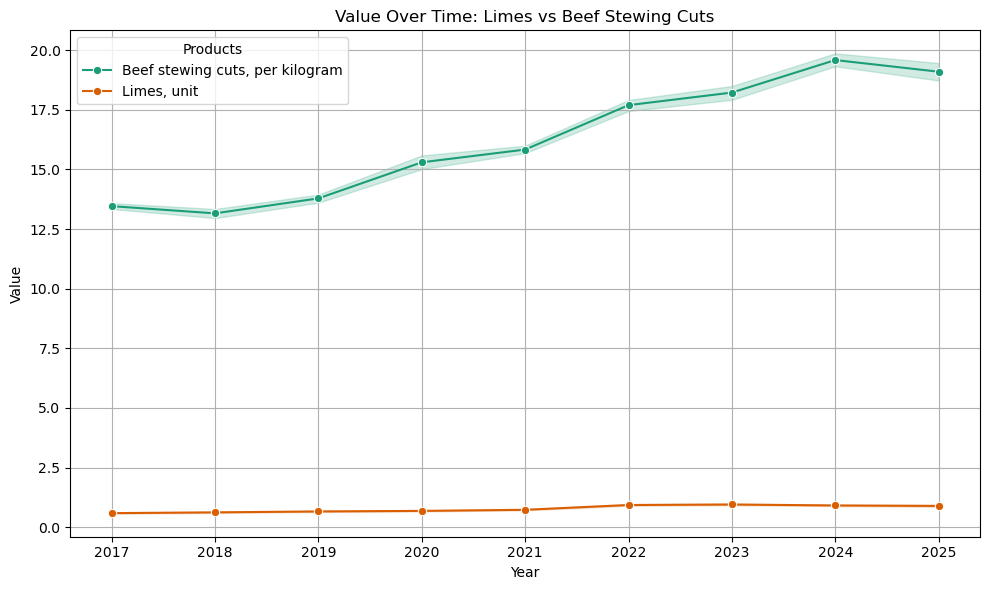

In [56]:
selected_products = df[df['Products'].isin(['Limes, unit', 'Beef stewing cuts, per kilogram'])]

plt.figure(figsize=(10, 6))
sns.lineplot(data=selected_products, x='Year', y='VALUE', hue='Products', marker='o', palette='Dark2')

plt.title("Value Over Time: Limes vs Beef Stewing Cuts")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()

<div dir="rtl"> אנו רואים שלאורך השנים המוצר שנמכר הכי הרבה נשמר בערך יחסית קבוע ולעומת זאת המוצר הכי נפוץ מהמוצרים עם הערך הכי גבוה, הערך שלו נמצא תמיד בעלייה לאורך השנים.

In [58]:
avg_value_products=df.groupby('Products')['VALUE'].mean().reset_index()
avg_value_products

,Products,VALUE
0,"Almonds, 200 grams",5.024165
1,"Apple juice, 2 litres",3.260436
2,"Apples, per kilogram",5.132458
3,"Avocado, unit",1.865983
4,"Baby food, 128 millilitres",1.428664
...,...,...
105,"White rice, 2 kilograms",8.774360
106,"White sugar, 2 kilograms",2.585937
107,"Whole chicken, per kilogram",6.048108
108,"Wieners, 400 grams",3.647570


<function matplotlib.pyplot.show(close=None, block=None)>

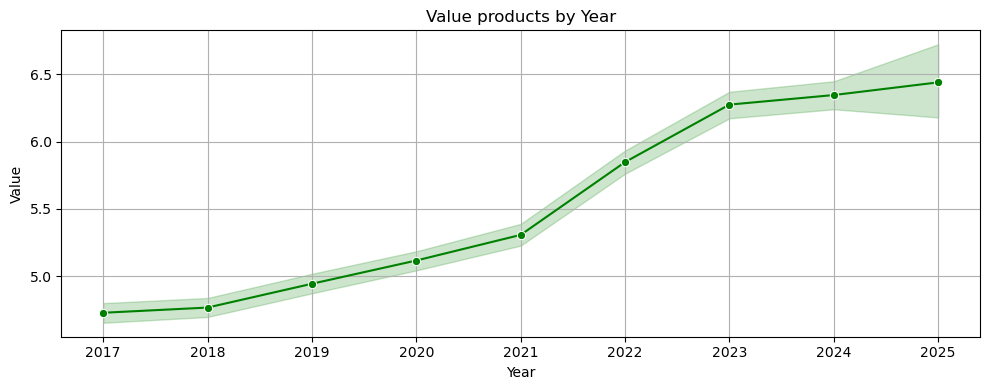

In [59]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Year', y='VALUE', marker='o', color='green')
plt.title('Value products by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show


<h2 dir="rtl" style="color:green"> מסקנה מספר 3 - השפעת הזמן על ערך המוצר </h2>

**<div dir="rtl"> בדקתי מהו המוצר עם הערך הכי גבוה ומהו המוצר עם הערך הכי נמוך, בנוסף גם בדקתי מהו הערך עם הצריכה הכי גבוהה ובמקרה זהו אותו מוצר עם הערך הכי נמוך. 
לאחר השוואה בין 2 המוצרים לאורך השנים רואים שישנה עלייה חדה במוצר עם הערך הכי גבוה אך המוצר עם הערך הכי נמוך ועם הצריכה הכי גבוהה נשאר יחסית קבוע. בדקתי את כלל המוצרים כדי לראות את התפלגות הערך שלהם לאורך השנים ורואים בבירור שהמחירים תמיד
לעולים, נשים לב שבשנים שיש את העלייה הכי חדה במחירים אלו השנים שאחרי מחלת הקורונה שידועה בתור מחלה שתקפה כלכלית את כל העולם. לכן מהנתונים רואים שהזמן והאקטואליה הם גורמים שמשפיעים בצורה משמעותית על עליית המחירים.**